In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
df = pd.read_csv(r"C:\Users\lnrka\OneDrive\Desktop\ELEVATE LABS\TASK_5\DATASET\train.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [8]:
df.shape

(891, 12)

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [10]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [11]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [12]:
df['Survived'].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

In [15]:
df['Age'] = df['Age'].fillna(df['Age'].median())

In [16]:
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

In [17]:
df = df.drop(columns=['Cabin'])

In [18]:
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

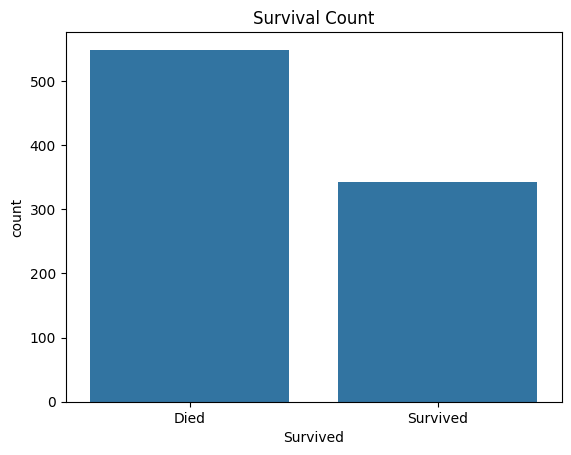

In [19]:
sns.countplot(x='Survived', data=df)
plt.title('Survival Count')
plt.xticks([0, 1], ['Died', 'Survived'])
plt.show()

Plot 1 — Survival Count:

Out of 891 passengers, around 550 died and 342 survived. This shows the dataset is slightly imbalanced — more people died than survived.

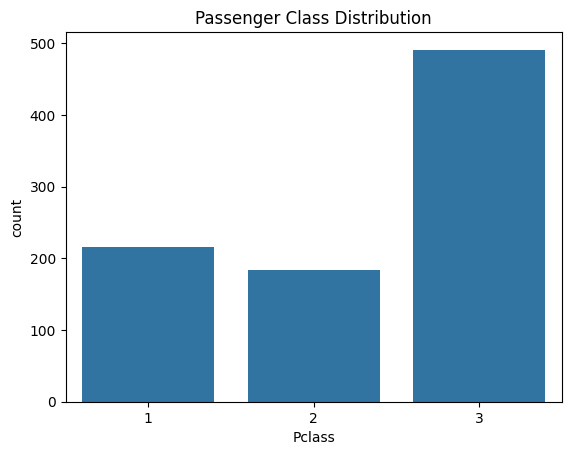

In [20]:
sns.countplot(x='Pclass', data=df)
plt.title('Passenger Class Distribution')
plt.show()

Plot 2 — Passenger Class:

Most passengers (~490) were in 3rd class, followed by 1st class (~216) and 2nd class (~184). The Titanic carried more lower-class passengers.

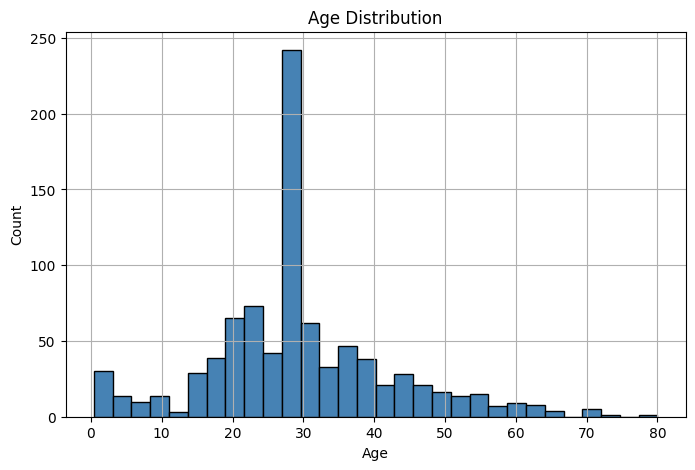

In [21]:
plt.figure(figsize=(8,5))
df['Age'].hist(bins=30, color='steelblue', edgecolor='black')
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

Plot 3 — Age Distribution:
Most passengers were between 20-35 years old. The distribution is slightly right-skewed. There's a big spike around age 28-30 which is the median we used to fill missing values.

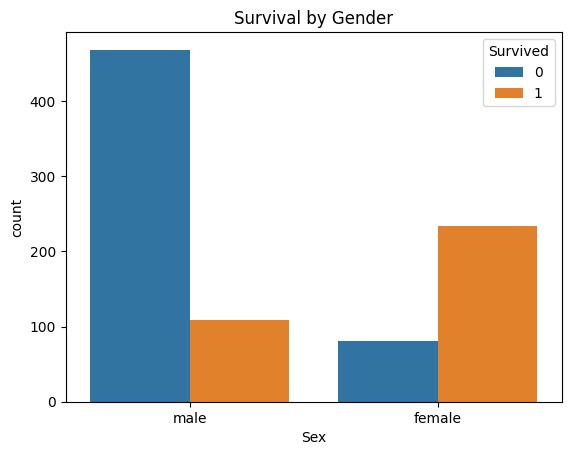

In [22]:
sns.countplot(x='Sex', hue='Survived', data=df)
plt.title('Survival by Gender')
plt.show()

Plot 4 — Survival by Gender:

Gender was a strong factor in survival. Most females survived (~235) while very few died (~80). For males it was the opposite — ~468 died and only ~110 survived. This reflects the "women and children first" evacuation policy.

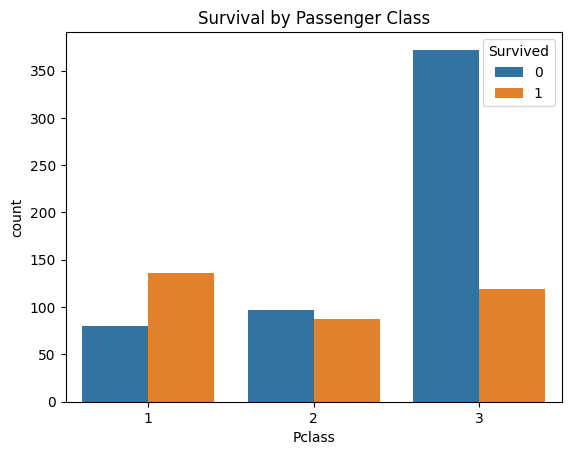

In [23]:
sns.countplot(x='Pclass', hue='Survived', data=df)
plt.title('Survival by Passenger Class')
plt.show()

Plot 5 — Survival by Class:

1st class passengers had the highest survival rate — more survived than died. 2nd class was nearly equal. 3rd class had the worst outcome — ~370 died vs only ~120 survived. Higher class = better survival chances.

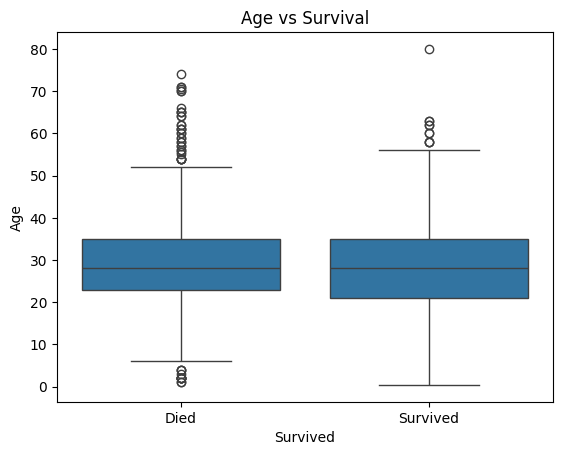

In [24]:
sns.boxplot(x='Survived', y='Age', data=df)
plt.title('Age vs Survival')
plt.xticks([0, 1], ['Died', 'Survived'])
plt.show()

Plot 6 — Age vs Survival (Boxplot):

The median age of both groups is similar (~28-29). Age alone was not a strong differentiator for survival. However there are more outliers (elderly passengers) in the Died group. Children had slightly better survival chances.

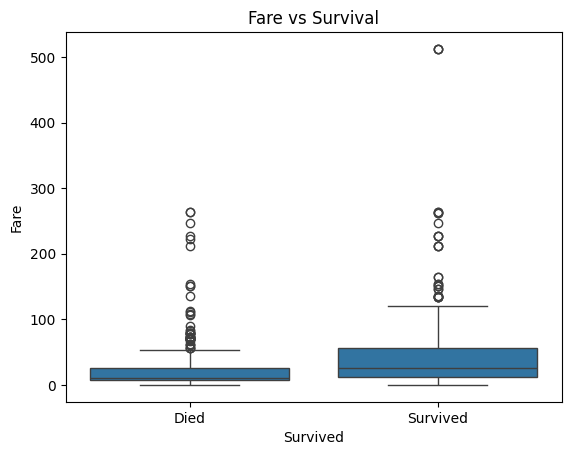

In [25]:
sns.boxplot(x='Survived', y='Fare', data=df)
plt.title('Fare vs Survival')
plt.xticks([0, 1], ['Died', 'Survived'])
plt.show()

Plot 7 — Fare vs Survival (Boxplot):

Passengers who survived paid significantly higher fares on average. The survived group has a much higher median fare and wider spread. This strongly links to Pclass — expensive tickets = 1st class = better survival. There are also extreme outliers (fare ~512) in the survived group.

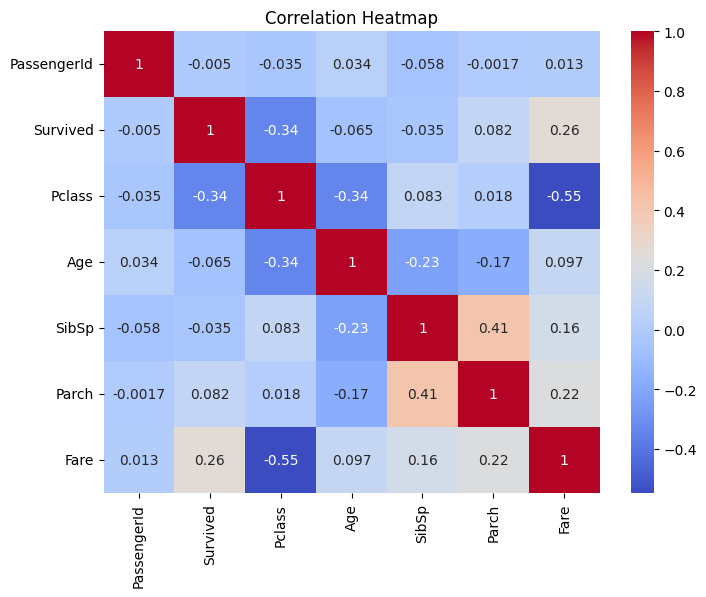

In [26]:
plt.figure(figsize=(8,6))
sns.heatmap(df.select_dtypes(include='number').corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

Plot 8 — Correlation Heatmap:

Fare and Survived have a positive correlation (0.26) — higher fare = better survival. Pclass and Survived have a negative correlation (-0.34) — higher class number = worse survival. Pclass and Fare are strongly negatively correlated (-0.55) — 1st class passengers paid much more. SibSp and Parch show moderate correlation (0.41) — families travelled together.

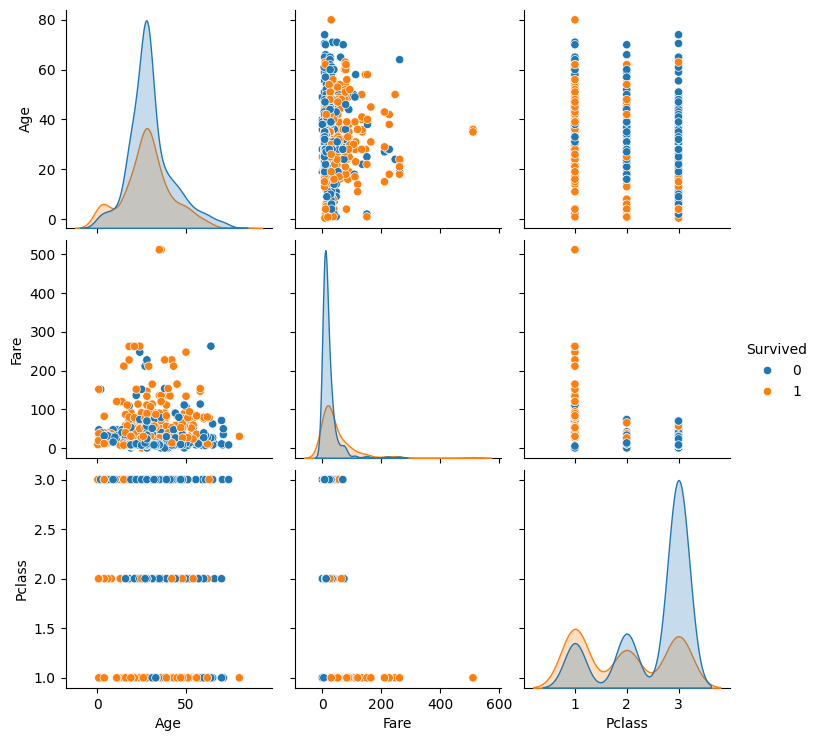

In [27]:
sns.pairplot(df[['Age', 'Fare', 'Pclass', 'Survived']], hue='Survived')
plt.show()

Plot 9 — Pairplot:

Orange dots (survived) tend to cluster at higher fare values. Blue dots (died) dominate at lower fares and higher Pclass. Age distributions of both groups overlap heavily confirming age was not the strongest survival factor. Fare is heavily right-skewed shown by the spike near zero.

## Summary of Findings

1. Only 38% of passengers survived — majority died
2. Gender was the strongest survival factor — females survived at a much higher rate
3. 1st class passengers had the best survival rate, 3rd class the worst
4. Higher fare strongly correlated with survival
5. Age was not a major differentiator — both groups had similar median ages
6. Most passengers were aged 20-35
7. 3rd class had the most passengers but worst survival outcome